# RecFlowTime — train and sample

Pick a dataset, train the model, draw samples, and look at them.

**The defaults below are exactly the configuration behind the reported results**
— 8,000 steps, 20 sampling steps, batch 128, `min_snr_floor` 0.1, training
seed 0 — so running this notebook unchanged reproduces the paper's model for
the chosen dataset. Lower `STEPS` for a quick look, at the cost of matching.

Training takes roughly 15 minutes on Sines on an Apple M-series GPU, and about
40, 30 and 87 minutes on Stocks, Energy and ECG respectively.

## 1. Dataset and hyperparameters

In [5]:
import os, sys, time, json
sys.path.insert(0, os.path.abspath("."))
os.environ.setdefault("OMP_NUM_THREADS", "1")

import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- choose here
DATASET = "sines"        # "sines" | "stocks" | "energy" | "ecg"

# Defaults are the reported configuration; changing any of them departs from it.
STEPS           = 8000   # training steps
SAMPLING_STEPS  = 20     # Euler steps per generated sequence (NFE)
BATCH_SIZE      = 128    # also the size of each transport assignment problem
LEARNING_RATE   = 2e-4
LOG_EVERY       = 100     # how often loss and gradient norm are recorded

OT_COUPLING     = True   # the transport coupling; False = independent pairing
USE_ROPE        = True   # rotary positions; False = fixed sinusoidal
USE_SELF_COND   = True   # self-conditioning
USE_MIN_SNR     = True   # min-SNR loss weighting
MIN_SNR_GAMMA   = 5.0
MIN_SNR_FLOOR   = 0.1    # lower bound on the weight; 0.0 gives plain min-SNR

SEED            = 0

# The reported runs evaluated a probe every 500 steps. The probe itself only
# measures, but it draws from the global RNG, so keeping it on is what makes
# this notebook reproduce those runs sample for sample. Set to 0 to skip it:
# the model is trained the same way, but the stream, and so the samples, differ.
PROBE_EVERY     = 500
# -----------------------------------------------------------------------------

# Sequence length and model width per dataset, as reported.
PLAN = {"sines": (64, 96), "energy": (96, 112), "stocks": (128, 128), "ecg": (192, 160)}
SEQ_LEN, D_MODEL = PLAN[DATASET]
print(f"{DATASET}: T={SEQ_LEN}, d_model={D_MODEL}, {STEPS} steps, {SAMPLING_STEPS} NFE")

sines: T=64, d_model=96, 8000 steps, 20 NFE


## 2. Data

Read from `data/splits/`, the same arrays every method in the paper uses, so no
difference in a score comes from a difference in data.

In [6]:
from recflowtime.data import make_dataset, split

X, _, meta = make_dataset(DATASET, seed=SEED, seq_len=SEQ_LEN, data_dir="data")
Xtr, Xva, Xte = split(X, seed=SEED)
print(f"train {tuple(Xtr.shape)}  val {tuple(Xva.shape)}  test {tuple(Xte.shape)}")
print(f"{meta['n_features']} features, values in [{X.min():.2f}, {X.max():.2f}]")

train (8000, 64, 4)  val (1000, 64, 4)  test (1000, 64, 4)
4 features, values in [-1.00, 1.00]


## 3. Model

In [7]:
from recflowtime.config import RecFlowTimeConfig
from recflowtime.train import RecFlowTimeTrainer

cfg = RecFlowTimeConfig.for_dataset(
    SEQ_LEN, meta["n_features"],
    **{"denoiser.d_model": D_MODEL,
       "denoiser.n_heads": 4,
       "denoiser.use_rope": USE_ROPE,
       "denoiser.use_self_cond": USE_SELF_COND,
       "core.ot_coupling": OT_COUPLING,
       "core.use_min_snr": USE_MIN_SNR,
       "core.min_snr_gamma": MIN_SNR_GAMMA,
       "core.min_snr_floor": MIN_SNR_FLOOR,
       "core.sampling_steps": SAMPLING_STEPS,
       "train.batch_size": BATCH_SIZE,
       "train.lr": LEARNING_RATE,
       "train.warmup_steps": STEPS,
       "train.joint_steps": 0,
       "train.log_every": LOG_EVERY,
       "train.val_every": 10 ** 9})
cfg.spectral.enabled = False     # no loss on generated samples

torch.manual_seed(SEED)
trainer = RecFlowTimeTrainer(cfg, Xtr, Xva, device=None, verbose=True)
print(f"{trainer.model.n_params():,} parameters")

device=mps  core=flow  denoiser params=523,108  ot_coupling=True  rope=True  self_cond=True  min_snr=True (floor 0.1)  extra terms: none
523,108 parameters


## 4. Train

`core` is the flow-matching loss. Probe lines report a discriminative and a
predictive score on 600 samples under a short protocol, so their absolute
values are not comparable with the final evaluation.

In [8]:
from recflowtime.metrics import discriminative_score, predictive_score

probe_history = []

def probe(tr, step):
    f = tr.generate(600, n_steps=cfg.core.sampling_steps)
    d = discriminative_score(Xte[:600], f, steps=300, device="cpu", seed=SEED)
    p = predictive_score(Xte[:600], f, steps=300, device="cpu", seed=SEED)
    probe_history.append({"step": step, "discriminative": d, "predictive": p})
    print(f"    [probe @ {step}] disc={d:.4f} pred={p:.4f}", flush=True)

t0 = time.time()
trainer.train_diffusion(warmup_steps=STEPS, joint_steps=0,
                        probe_every=PROBE_EVERY or 10 ** 9,
                        probe_fn=probe if PROBE_EVERY else None)
train_minutes = (time.time() - t0) / 60
print(f"\ntrained in {train_minutes:.1f} min")


flow warmup  (8000 steps)
  step    100  core=0.75778  total=0.75778  grad_norm=0.53634
  step    200  core=0.48444  total=0.48444  grad_norm=1.46130
  step    300  core=0.25308  total=0.25308  grad_norm=2.29178
  step    400  core=0.17794  total=0.17794  grad_norm=1.82874
  step    500  core=0.24096  total=0.24096  grad_norm=8.99373
    [probe @ 500] disc=0.5000 pred=0.6067
  step    600  core=0.11797  total=0.11797  grad_norm=1.08307
  step    700  core=0.10098  total=0.10098  grad_norm=0.77703
  step    800  core=0.11317  total=0.11317  grad_norm=0.92574
  step    900  core=0.10848  total=0.10848  grad_norm=1.71532
  step   1000  core=0.09981  total=0.09981  grad_norm=1.52024
    [probe @ 1000] disc=0.5000 pred=0.3197
  step   1100  core=0.07279  total=0.07279  grad_norm=0.41765
  step   1200  core=0.06232  total=0.06232  grad_norm=0.47692
  step   1300  core=0.07966  total=0.07966  grad_norm=0.94459
  step   1400  core=0.07396  total=0.07396  grad_norm=0.90402
  step   1500  core=

## 5. Sample

In [9]:
n_gen = max(len(Xte), 1000)
t0 = time.time()
fake = trainer.generate(n_gen, n_steps=SAMPLING_STEPS)
gen_seconds = time.time() - t0
print(f"{n_gen} sequences in {gen_seconds:.1f}s "
      f"({1000 * gen_seconds / n_gen:.2f} ms/sequence at {SAMPLING_STEPS} NFE)")

1000 sequences in 4.2s (4.21 ms/sequence at 20 NFE)


## 6. Look at the samples

Real in red, generated in blue, stacked rather than overlaid so individual
sequences stay readable.

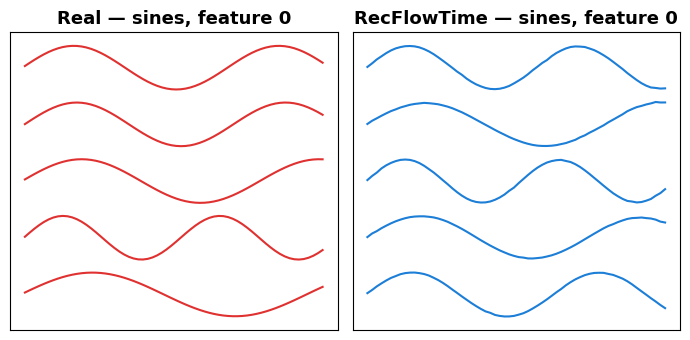

roughness relative to real data: 1.28x


In [18]:
FEATURE   = 0     # which channel to plot
N_SHOW    = 5     # sequences per panel
PLOT_SEED = 0

rng = np.random.default_rng(PLOT_SEED)
real_np, fake_np = Xte.numpy(), fake.numpy()
span = float(np.median(real_np[:, :, FEATURE].max(1) - real_np[:, :, FEATURE].min(1)))

fig, ax = plt.subplots(1, 2, figsize=(7, 3.5), sharey=True)
for a, (arr, colour, title) in zip(ax, [(real_np, "#E03131", "Real"),
                                        (fake_np, "#1C7ED6", "RecFlowTime")]):
    for m, k in enumerate(rng.choice(len(arr), N_SHOW, replace=False)):
        a.plot(arr[k, :, FEATURE] - m * 1.3 * span, color=colour, lw=1.5)
    a.set_title(f"{title} — {DATASET}, feature {FEATURE}", fontsize=13, fontweight="bold")
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

# Mean absolute second difference, as a ratio to the real data: 1.0 means the
# samples are exactly as locally smooth as the data.
rough = (np.abs(np.diff(fake_np, n=2, axis=1)).mean()
         / np.abs(np.diff(real_np, n=2, axis=1)).mean())
print(f"roughness relative to real data: {rough:.2f}x")

## 7. Save, so `02_evaluate.ipynb` can score these samples

In [11]:
OUT_DIR = os.path.join("results", "notebook")
os.makedirs(OUT_DIR, exist_ok=True)
tag = f"{DATASET}_ours"

np.savez_compressed(os.path.join(OUT_DIR, f"{tag}_data.npz"),
                    real_test=Xte.numpy(), real_train=Xtr[:2000].numpy(),
                    real_val=Xva.numpy(), generated=fake.numpy())
torch.save({"ema_state": trainer.ema.model.state_dict(),
            "model_state": trainer.model.state_dict(),
            "config": json.loads(cfg.to_json()), "meta": meta},
           os.path.join(OUT_DIR, f"{tag}_ckpt.pt"))
json.dump({"dataset": DATASET, "variant": "ours", "seed": SEED, "meta": meta,
           "train_time_s": train_minutes * 60, "gen_time_s": gen_seconds,
           "denoiser_params": trainer.model.n_params(), "probe": probe_history,
           "budget": {"warmup_steps": STEPS, "joint_steps": 0},
           "config": json.loads(cfg.to_json())},
          open(os.path.join(OUT_DIR, f"{tag}.json"), "w"), indent=2, default=float)

print(f"wrote {tag}_* to {OUT_DIR}")
print("Open 02_evaluate.ipynb to score them.")

wrote sines_ours_* to results/notebook
Open 02_evaluate.ipynb to score them.
